In [65]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Chemin du fichier csv
chemin_fichier = "E://Projet_SQL//logements_sociaux_fr_brut.csv"

df = pd.read_csv(chemin_fichier, sep=';', encoding='utf-8')  # Ou iso-8859-1 si ça coince
print(df.head(5))

  Code Commune   Département               Région  code_region  \
0        28040  Eure-et-Loir  CENTRE-VAL DE LOIRE         24.0   
1        28070  Eure-et-Loir  CENTRE-VAL DE LOIRE         24.0   
2        28085  Eure-et-Loir  CENTRE-VAL DE LOIRE         24.0   
3        28090  Eure-et-Loir  CENTRE-VAL DE LOIRE         24.0   
4        28227  Eure-et-Loir  CENTRE-VAL DE LOIRE         24.0   

   Taux de logements sociaux (%)  \
0                            0.0   
1                           10.0   
2                           31.0   
3                            0.0   
4                           16.0   

                                                geom  \
0  {"coordinates": [[[[1.209956998, 48.520591349]...   
1  {"coordinates": [[[[1.495640798, 48.473915202]...   
2  {"coordinates": [[[[1.515737493, 48.427185829]...   
3  {"coordinates": [[[[1.015929514, 48.675554898]...   
4  {"coordinates": [[[[1.583035441, 48.604331377]...   

                    centroid code_departement    

In [67]:
df.shape

(35228, 11)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35228 entries, 0 to 35227
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code Commune                   35228 non-null  object 
 1   Département                    34815 non-null  object 
 2   Région                         34815 non-null  object 
 3   code_region                    34815 non-null  float64
 4   Taux de logements sociaux (%)  35228 non-null  float64
 5   geom                           34802 non-null  object 
 6   centroid                       34815 non-null  object 
 7   code_departement               34815 non-null  object 
 8   Nom Commune                    34815 non-null  object 
 9   epci                           34811 non-null  object 
 10  code_epci                      34811 non-null  float64
dtypes: float64(3), object(8)
memory usage: 3.0+ MB


In [69]:
df.isnull().sum()

Code Commune                       0
Département                      413
Région                           413
code_region                      413
Taux de logements sociaux (%)      0
geom                             426
centroid                         413
code_departement                 413
Nom Commune                      413
epci                             417
code_epci                        417
dtype: int64

### Suppression de lignes incomplètes

In [70]:
df_clean = df.dropna()
print(df_clean.shape)

(34798, 11)


In [71]:
df_clean.isnull().sum()

Code Commune                     0
Département                      0
Région                           0
code_region                      0
Taux de logements sociaux (%)    0
geom                             0
centroid                         0
code_departement                 0
Nom Commune                      0
epci                             0
code_epci                        0
dtype: int64

In [72]:
df_clean.describe()

,code_region,Taux de logements sociaux (%),code_epci
count,34798.000000,34798.000000,3.479800e+04
mean,52.453417,3.988994,2.125194e+08
std,24.193964,7.361732,2.002169e+07
min,11.000000,0.000000,2.000002e+08
25%,28.000000,0.000000,2.000660e+08
50%,44.000000,0.000000,2.000697e+08
75%,76.000000,5.000000,2.410004e+08
max,94.000000,157.000000,2.495005e+08


Remettre à zéro l'index le nouveau df sans lignes vides : df_clean

In [73]:
df_clean.reset_index(drop=True, inplace=True)

Afficher les colonnes

In [74]:
df_clean.columns

Index(['Code Commune', 'Département', 'Région', 'code_region',
       'Taux de logements sociaux (%)', 'geom', 'centroid', 'code_departement',
       'Nom Commune', 'epci', 'code_epci'],
      dtype='object')

Effacer les colonnes unitiles de df_clean

In [75]:
colonnes_utiles = ['Code Commune', 'Nom Commune', 'Département', 'Région', 'Taux de logements sociaux (%)', 'geom']
df_reduit = df_clean[colonnes_utiles]

In [76]:
df_reduit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34798 entries, 0 to 34797
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code Commune                   34798 non-null  object 
 1   Nom Commune                    34798 non-null  object 
 2   Département                    34798 non-null  object 
 3   Région                         34798 non-null  object 
 4   Taux de logements sociaux (%)  34798 non-null  float64
 5   geom                           34798 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.6+ MB


In [77]:
df_reduit.head(5)

,Code Commune,Nom Commune,Département,Région,Taux de logements sociaux (%),geom
0,28040,Billancelles,Eure-et-Loir,CENTRE-VAL DE LOIRE,0.0,"{""coordinates"": [[[[1.209956998, 48.520591349]..."
1,28070,Champhol,Eure-et-Loir,CENTRE-VAL DE LOIRE,10.0,"{""coordinates"": [[[[1.495640798, 48.473915202]..."
2,28085,Chartres,Eure-et-Loir,CENTRE-VAL DE LOIRE,31.0,"{""coordinates"": [[[[1.515737493, 48.427185829]..."
3,28090,Les Châtelets,Eure-et-Loir,CENTRE-VAL DE LOIRE,0.0,"{""coordinates"": [[[[1.015929514, 48.675554898]..."
4,28227,Maintenon,Eure-et-Loir,CENTRE-VAL DE LOIRE,16.0,"{""coordinates"": [[[[1.583035441, 48.604331377]..."


Analyse exploratoire

In [78]:
df_reduit['Taux de logements sociaux (%)'].mean()

3.988993620323007

In [79]:
df_reduit['Taux de logements sociaux (%)'].unique()

array([  0.,  10.,  31.,  16.,   4.,   7.,   6.,   5.,  18.,   1.,  14.,
         9.,  11.,   2.,  17.,  26.,  23.,  12.,   8.,   3.,  13.,  22.,
        30.,  20.,  15.,  42.,  29.,  41.,  19.,  46.,  32.,  21.,  34.,
        47.,  35.,  33.,  25.,  27.,  24.,  37.,  45.,  40.,  63.,  38.,
        39.,  28.,  44.,  71.,  43.,  55.,  58.,  52.,  56.,  69.,  54.,
        36.,  53.,  59.,  48.,  50., 157.,  49.,  94.,  68.,  62.,  57.,
        60.,  65.,  51.,  86.])

In [80]:
# Identifier où est la valeur aberrante qui est 157
df_reduit[df_reduit['Taux de logements sociaux (%)'] > 100]

,Code Commune,Nom Commune,Département,Région,Taux de logements sociaux (%),geom
6939,71085,Change,Saône-et-Loire,BOURGOGNE-FRANCHE-COMTÉ,157.0,"{""coordinates"": [[[[4.649693474, 46.941475689]..."


In [81]:
#Prendre le df_reduit entier sans la commune '71085'
df_reduit = df_reduit[df_reduit['Code Commune'] != '71085']

In [82]:
# Vérifier que la commune '71085' a été supprimée
df_reduit[df_reduit['Code Commune'] == '71085']

,Code Commune,Nom Commune,Département,Région,Taux de logements sociaux (%),geom


In [83]:
# Vérifier que le taux de 157 n'est plus sur la base de données
df_reduit['Taux de logements sociaux (%)'].unique()

array([ 0., 10., 31., 16.,  4.,  7.,  6.,  5., 18.,  1., 14.,  9., 11.,
        2., 17., 26., 23., 12.,  8.,  3., 13., 22., 30., 20., 15., 42.,
       29., 41., 19., 46., 32., 21., 34., 47., 35., 33., 25., 27., 24.,
       37., 45., 40., 63., 38., 39., 28., 44., 71., 43., 55., 58., 52.,
       56., 69., 54., 36., 53., 59., 48., 50., 49., 94., 68., 62., 57.,
       60., 65., 51., 86.])

In [84]:
# # Vérifier le type de variables
df_reduit.dtypes

Code Commune                      object
Nom Commune                       object
Département                       object
Région                            object
Taux de logements sociaux (%)    float64
geom                              object
dtype: object

In [85]:
print(df_reduit.shape)

(34797, 6)


In [86]:
# Réinitialiser l'index
df_reduit.reset_index(drop=True, inplace=True)

Création du nouveau csv propre, sans données aberrantes ni données manquantes

In [87]:
# df_reduit.to_csv('logements_sociaux_fr_propre.csv', index=False)

In [88]:
df_reduit['Taux de logements sociaux (%)'].value_counts()

0.0     18519
2.0      1856
3.0      1742
1.0      1615
4.0      1470
        ...  
68.0        2
71.0        2
94.0        1
65.0        1
86.0        1
Name: Taux de logements sociaux (%), Length: 69, dtype: int64

In [89]:
# Combien de valeurs différentes de taux de logement sociaux existent ?
df_reduit['Taux de logements sociaux (%)'].nunique()

69

In [90]:
# Statistiques de base
df_reduit['Taux de logements sociaux (%)'].describe()

count    34797.000000
mean         3.984596
std          7.315995
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max         94.000000
Name: Taux de logements sociaux (%), dtype: float64

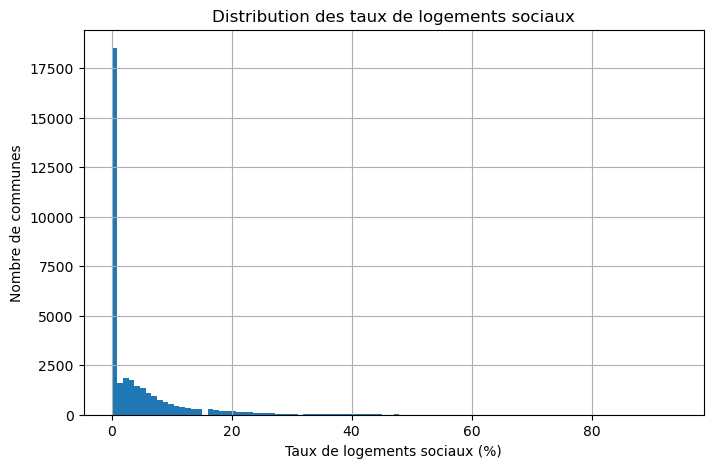

In [91]:
# Distribution visuelle simple du taux de logement sociaux
plt.figure(figsize=(8,5))
df_reduit['Taux de logements sociaux (%)'].hist(bins=100)
plt.xlabel('Taux de logements sociaux (%)')
plt.ylabel('Nombre de communes')
plt.title('Distribution des taux de logements sociaux')
plt.grid(True)
plt.show()

In [92]:
# Vérifier combien de communes en France sont à 0% de logements sociaux
nb_communes_total = df_reduit.shape[0]
nb_sans_logement_social = (df_reduit['Taux de logements sociaux (%)'] == 0).sum()
pourcentage = round((nb_sans_logement_social / nb_communes_total) * 100, 2)

print(f"Communes avec 0% de logements sociaux : {nb_sans_logement_social} sur {nb_communes_total} ({pourcentage}%)")

Communes avec 0% de logements sociaux : 18519 sur 34797 (53.22%)


In [93]:
# Cela montre que :
# - Sur la totalité de communes analysées (34797) 18519 n'offrent aucun logement social, soit 53,22% des communes.
# - La loi SRU impose des quotas de logements sociaux uniquement aux communes de plus de 3 500 habitants (ou 1 500 en Île-de-France).

In [94]:
# identifier les communes avec le plus fort taux de logement sociaux
cols = ['Code Commune', 'Nom Commune', 'Taux de logements sociaux (%)']
df_reduit.sort_values(by='Taux de logements sociaux (%)', ascending=False)[cols].head(5)

,Code Commune,Nom Commune,Taux de logements sociaux (%)
8695,78615,Thiverval-Grignon,94.0
30531,57058,Behren-lès-Forbach,86.0
2729,57207,Farébersviller,71.0
32782,27701,Val-de-Reuil,71.0
5234,93030,Dugny,69.0


In [95]:
# Calculler la moyenne du taux de logements sociaux par département
df_reduit.groupby('Département')['Taux de logements sociaux (%)'].mean().sort_values(ascending=False).head(10)

Département
Seine-Saint-Denis    35.225000
Hauts-de-Seine       27.861111
Val-de-Marne         27.723404
Paris                21.000000
Essonne              10.587629
Nord                 10.527778
Val-d'Oise            9.923913
Bouches-du-Rhône      9.644068
Maine-et-Loire        9.523256
Rhône                 9.468165
Name: Taux de logements sociaux (%), dtype: float64

In [96]:
df_reduit.groupby('Région')['Taux de logements sociaux (%)'].mean().sort_values(ascending=False).head(10)

Région
ÎLE-DE-FRANCE                 9.887224
BRETAGNE                      5.488353
AUVERGNE-RHÔNE-ALPES          5.340864
PAYS DE LA LOIRE              5.339853
HAUTS-DE-FRANCE               5.261685
CENTRE-VAL DE LOIRE           4.941946
PROVENCE-ALPES-CÔTE D'AZUR    4.672669
NORMANDIE                     4.526792
GRAND EST                     2.955265
NOUVELLE-AQUITAINE            2.556072
Name: Taux de logements sociaux (%), dtype: float64